In [35]:
!pip install -q torchmetrics iterative-stratification optuna shap
!pip install -q huggingface_hub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 34.1 MB/s eta 0:00:00


In [ ]:
from huggingface_hub import notebook_login
notebook_login()


In [36]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit

from datasets import load_dataset

pd.set_option("display.max_columns", 136)

root = "ADS599-Capstone/modeling_data"

df_patient = load_dataset(path=root, name='full_patient_state', split='full_patient_state').to_pandas()
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

In [37]:
torch.manual_seed(10)
np.random.seed(10)
torch.cuda.manual_seed(10)
torch.cuda.manual_seed_all(10)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using device: {device}")


Using cuda device


In [38]:
# Keep only unique state rows per stay
drop_cols = df_patient.columns[4:].tolist()
drop_cols.remove("time_since_last_hrs")
drop_cols.append("ed_stay_id")
df_model = df_patient.drop_duplicates(subset=drop_cols).copy()

print(f"Original rows: {len(df_patient):,}")
print(f"Filtered rows: {len(df_model):,}")
print(f"Reduction:     {1 - len(df_model)/len(df_patient):.1%}")
print("Terminal event distribution:")
print(df_model.drop_duplicates("ed_stay_id")["terminal_event"].value_counts())


Original rows: 6,551,723
Filtered rows: 1,122,668
Reduction:     82.9%
Terminal event distribution:
terminal_event
DISCHARGE_ED      38130
DISCHARGE_WARD    27834
ICU               18247
Name: count, dtype: int64


# Preprocess and One-Hot-Encode Categorical Columns

In [39]:
# Map Gender
gender_map = {"F": 1, "M": 0}
df_model["gender"] = df_model["gender"].map(gender_map)

# Change acuity to integer
df_model["acuity"] = df_model["acuity"].astype(int)

# Mask height and weight
df_model["height_missing"] = df_model["height"].isna().astype(int)
df_model["weight_missing"] = df_model["weight"].isna().astype(int)
df_model[["height", "weight"]] = df_model[["height", "weight"]].fillna(0)

# Create pain_missing column and convert the Other category to 0
df_model["pain_missing"] = (df_model["current_pain"] == "Other").astype(int)
df_model["current_pain"] = pd.to_numeric(df_model["current_pain"], errors="coerce").fillna(0)

# Mask admission type then one hot encode admission and arrival
df_model["admission_missing"] = df_model["admission_type"].isna().astype(int)
at_dummies = pd.get_dummies(df_model["admission_type"], prefix="admission_type", dummy_na=False, dtype=int)
arrival_dummies = pd.get_dummies(df_model["arrival_transport"], prefix="arrival_transport", dtype=int)
df_model_updated = pd.concat([df_model, at_dummies, arrival_dummies], axis=1).drop(columns=["admission_type", "arrival_transport"])


# Isolate Columns

In [40]:
# Columns out of order so this pieces all the state cols together
vitals = [c for c in df_model_updated.loc[:, "current_temperature":"dbp_rate"].columns if not c.endswith("_rate") and not c.endswith("_delta")]
med_cols = [c for c in df_model_updated.columns if c.startswith("recon")]
admission_cols = at_dummies.columns.to_list() + ["admission_missing"]
arrival_cols = arrival_dummies.columns.to_list()

# Definitive list of patient state cols (124 features)
state_cols = df_model_updated.columns[4:71].to_list() + ["gender", "anchor_age", "acuity", "height", "height_missing", "weight_missing", "pain_missing"] + med_cols + vitals + admission_cols + arrival_cols

print(f"State cols: {len(state_cols)}")


State cols: 124


# Sequence Modeling

## Split Data

In [46]:
pad_length = df_modeling.groupby('ed_stay_id').size().max()

# Encode terminal event: discharge=0, ICU=1
terminal_event_mapping = {"DISCHARGE_WARD": 0, "DISCHARGE_ED": 0, "ICU": 1}
df_model_updated["terminal_code"] = df_model_updated["terminal_event"].map(terminal_event_mapping)

valid_stays = df_model_updated.groupby("ed_stay_id").size()
valid_stays = valid_stays[valid_stays < pad_length].index
df_modeling = df_model_updated[df_model_updated["ed_stay_id"].isin(valid_stays)]
print(f"Stays after length filter: {df_modeling['ed_stay_id'].nunique():,}")


Stays after length filter: 84,210


This drop stays from the group that last less than 400 time steps.  Removes less than 1000 records from the group of 84k

In [47]:
def pad_stays(df, max_len=pad_length):
    grouped = df.groupby("ed_stay_id")
    states, labels, lengths = [], [], []

    for stay_id, group in grouped:
        s = group[state_cols].values.astype(np.float32)
        pad_len = max_len - len(s)
        s = np.pad(s, ((0, pad_len), (0, 0)))  # pad rows, not features
        label = int(group["terminal_code"].iloc[0])  # single label per stay
        states.append(s)
        labels.append(label)
        lengths.append(len(group))

    return np.stack(states), np.array(labels, dtype=np.int64), np.array(lengths)


In [48]:
stay_labels = (
    df_modeling.drop_duplicates("ed_stay_id")[["ed_stay_id", "terminal_code"]]
    .reset_index(drop=True)
)

train_split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=10)
train_idx, test_idx = next(train_split.split(stay_labels, stay_labels["terminal_code"]))

train_stays = set(stay_labels.iloc[train_idx]["ed_stay_id"])
test_stays  = set(stay_labels.iloc[test_idx]["ed_stay_id"])

df_train = df_modeling[df_modeling["ed_stay_id"].isin(train_stays)].copy()
df_test  = df_modeling[df_modeling["ed_stay_id"].isin(test_stays)].copy()

print(f"Train stays: {df_train['ed_stay_id'].nunique():,}")
print(df_train.drop_duplicates('ed_stay_id')['terminal_event'].value_counts())
print(f"\nTest stays:  {df_test['ed_stay_id'].nunique():,}")
print(df_test.drop_duplicates('ed_stay_id')['terminal_event'].value_counts())
print(f"\nOverlap: {train_stays.intersection(test_stays)}")


Train stays: 67,368
terminal_event
DISCHARGE_ED      30513
DISCHARGE_WARD    22258
ICU               14597
Name: count, dtype: int64

Test stays:  16,842
terminal_event
DISCHARGE_ED      7617
DISCHARGE_WARD    5576
ICU               3649
Name: count, dtype: int64

Overlap: set()


## Scale and Pad Data

In [49]:
scale = StandardScaler()
scaling_cols = vitals + ['anchor_age', 'weight', 'height', 'time_since_last_hrs']

df_train[scaling_cols] = scale.fit_transform(df_train[scaling_cols])
df_test[scaling_cols] = scale.transform(df_test[scaling_cols])

In [50]:
missing = [c for c in state_cols if c not in df_train.columns]
extra = [c for c in df_train.columns if c not in state_cols + ["ed_stay_id", "subject_id", "hadm_id", "time", "terminal_event", "terminal_code", "ed_boarding"]]
print(f"In state_cols but not in df_train: {missing}")
print(f"In df_train but not accounted for: {extra}")


In state_cols but not in df_train: []
In df_train but not accounted for: ['temperature_delta', 'temperature_rate', 'heartrate_delta', 'heartrate_rate', 'resprate_delta', 'resprate_rate', 'o2sat_delta', 'o2sat_rate', 'sbp_delta', 'sbp_rate', 'dbp_delta', 'dbp_rate', 'observe', 'dispense_meds', 'ward_transfer', 'discharge', 'transfer_icu', 'ecg_ordered', 'rad_ordered', 'vitals_checked', 'labs_ordered', 'micro_ordered']


In [51]:
df_train.drop(columns=extra, inplace=True)
df_test.drop(columns=extra, inplace=True)

In [52]:
# Configurations
batch_size = 16
input_size = 124
hidden_size = 256
num_layers = 2
dropout = 0.2
num_classes = 2   # discharge=0, ICU=1
epochs = 5


In [53]:
# Prep train
s_train, y_train, train_len = pad_stays(df_train)
s_train   = torch.tensor(s_train)
y_train   = torch.tensor(y_train)   # (N,) int64
train_len = torch.tensor(train_len)

# Prep test
s_test, y_test, test_len = pad_stays(df_test)
s_test   = torch.tensor(s_test)
y_test   = torch.tensor(y_test)
test_len = torch.tensor(test_len)

train_loader = DataLoader(
    TensorDataset(s_train, y_train, train_len),
    batch_size=batch_size, shuffle=True,
    generator=torch.Generator().manual_seed(10),
)
test_loader = DataLoader(
    TensorDataset(s_test, y_test, test_len),
    batch_size=batch_size, shuffle=False,
)

print(f"State dim:   {s_train.shape[2]}")
print(f"Train stays: {s_train.shape[0]:,}")
print(f"Test stays:  {s_test.shape[0]:,}")
print(f"Train class: discharge={(y_train==0).sum():,}  icu={(y_train==1).sum():,}")
print(f"Test  class: discharge={(y_test==0).sum():,}  icu={(y_test==1).sum():,}")


State dim:   124
Train stays: 67,368
Test stays:  16,842
Train class: discharge=52,771  icu=14,597
Test  class: discharge=13,193  icu=3,649


# Modeling Set Up

In [54]:
class SequenceModeling(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        _, (h_n, _) = self.lstm(packed)
        last_hidden = h_n[-1]  # (B, hidden_size) top layer final hidden state
        return self.fc(last_hidden)  # (B, num_classes) logits

seq_model = SequenceModeling().to(device)
print(seq_model)


SequenceModeling(
  (lstm): LSTM(124, 256, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)


In [55]:
# Class weight to handle ICU minority class
stay_labels_train = df_train.drop_duplicates("ed_stay_id")["terminal_code"].values
labels_all   = torch.tensor(stay_labels_train)
n_discharge  = (labels_all == 0).sum().float()
n_icu        = (labels_all == 1).sum().float()
class_weight = torch.tensor([1.0, (n_discharge / n_icu).item()]).to(device)
print(f"Class weights: discharge={class_weight[0]:.2f}  icu={class_weight[1]:.2f}")

learning_rate = 1e-4
loss_fn   = nn.CrossEntropyLoss(weight=class_weight)
optimizer = torch.optim.AdamW(seq_model.parameters(), lr=learning_rate)


Class weights: discharge=1.00  icu=3.62


## Training Loop

In [56]:
from torchmetrics.classification import MulticlassF1Score
f1 = MulticlassF1Score(num_classes=num_classes, average="macro")
f1_per_class = MulticlassF1Score(num_classes=num_classes, average="none")


In [19]:
def training_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    total_loss = 0
    for batch, (X, y, lengths) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        pred = model(X, lengths)  # (B, 2) logits
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        if batch % 200 == 0:
            current = batch * batch_size + len(X)
            print(f"loss: {loss.item():>7.4f} [{current:>5d}/{size:>5d}]")
    return total_loss / len(dataloader)


In [20]:
def evaluation_loop(dataloader, model, loss_fn):
    num_batches = len(dataloader)
    test_loss = 0
    preds, true_y = [], []

    model.eval()
    with torch.no_grad():
        for X, y, lengths in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X, lengths)  # (B, 2) logits
            test_loss += loss_fn(pred, y).item()
            preds.append(torch.softmax(pred, dim=-1).cpu())
            true_y.append(y.cpu())

    final_preds = torch.cat(preds, dim=0)   # (N, 2) probs
    true_labels = torch.cat(true_y, dim=0)  # (N,) int64

    test_loss /= num_batches
    f1_macro = f1(final_preds, true_labels).item()
    f1_per   = f1_per_class(final_preds, true_labels)
    print(f"\nAvg Loss: {test_loss:.4f}  F1_Macro: {f1_macro:.4f}")
    for cls, score in zip(["discharge", "icu"], f1_per.tolist()):
        print(f"  {cls}: {score:.4f}")

    return final_preds, true_labels, test_loss


In [63]:
import os, tempfile
from huggingface_hub import HfApi

train_losses = []
eval_losses  = []

# Early stopping config
patience          = 3
best_eval_loss    = float("inf")
epochs_no_improve = 0
best_model_state  = None
best_epoch        = 0
hf_repo_id        = "ADS599-Capstone/disposition_lstm_model"
hf_filename       = "lstm_model_best.pt"

hf_api = HfApi()
hf_api.create_repo(hf_repo_id, exist_ok=True, private=True)

for epoch in range(epochs):
    print(f"\nEpoch {epoch + 1}------------------------------")
    t_loss = training_loop(train_loader, seq_model, loss_fn, optimizer)
    train_losses.append(t_loss)
    final_preds, true_labels, e_loss = evaluation_loop(test_loader, seq_model, loss_fn)
    eval_losses.append(e_loss)

    if e_loss < best_eval_loss:
        best_eval_loss    = e_loss
        best_epoch        = epoch + 1
        best_model_state  = {k: v.clone() for k, v in seq_model.state_dict().items()}
        epochs_no_improve = 0
        # Save to HuggingFace Hub
        with tempfile.NamedTemporaryFile(suffix=".pt", delete=False) as tmp:
            torch.save(best_model_state, tmp.name)
            tmp_path = tmp.name
        hf_api.upload_file(
            path_or_fileobj=tmp_path,
            path_in_repo=hf_filename,
            repo_id=hf_repo_id,
        )
        os.unlink(tmp_path)
        print(f"  ** New best eval loss: {best_eval_loss:.4f} (saved to {hf_repo_id}/{hf_filename})")
    else:
        epochs_no_improve += 1
        print(f"  No improvement for {epochs_no_improve}/{patience} epochs")
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch + 1}. Best was epoch {best_epoch}.")
            break

# Restore best model
if best_model_state is not None:
    seq_model.load_state_dict(best_model_state)
    print(f"\nRestored model from epoch {best_epoch} (eval loss: {best_eval_loss:.4f})")
    final_preds, true_labels, _ = evaluation_loop(test_loader, seq_model, loss_fn)


Epoch 1------------------------------
loss:  0.6910 [   16/67368]
loss:  0.3446 [ 3216/67368]
loss:  0.2214 [ 6416/67368]
loss:  0.1227 [ 9616/67368]
loss:  0.0379 [12816/67368]
loss:  0.0247 [16016/67368]
loss:  0.2114 [19216/67368]
loss:  0.2332 [22416/67368]
loss:  0.2680 [25616/67368]
loss:  0.0404 [28816/67368]
loss:  0.2371 [32016/67368]
loss:  0.0836 [35216/67368]
loss:  0.1127 [38416/67368]
loss:  0.1267 [41616/67368]
loss:  0.1933 [44816/67368]
loss:  0.1109 [48016/67368]
loss:  0.1008 [51216/67368]
loss:  0.2992 [54416/67368]
loss:  0.0734 [57616/67368]
loss:  0.1254 [60816/67368]
loss:  0.1233 [64016/67368]
loss:  0.1200 [67216/67368]

Avg Loss: 0.1392  F1_Macro: 0.9171
  discharge: 0.9618
  icu: 0.8724
  ** New best eval loss: 0.1392 (saved)
Epoch 2------------------------------
loss:  0.0260 [   16/67368]
loss:  0.0165 [ 3216/67368]
loss:  0.0993 [ 6416/67368]
loss:  0.2081 [ 9616/67368]
loss:  0.0282 [12816/67368]
loss:  0.0822 [16016/67368]
loss:  0.0317 [19216/67368]
lo

In [57]:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

def build_model(hs, nl, dr):
    class _Model(nn.Module):
        def __init__(self):
            super().__init__()
            self.lstm = nn.LSTM(input_size=input_size, hidden_size=hs,
                                num_layers=nl, batch_first=True,
                                dropout=dr if nl > 1 else 0.0)
            self.fc = nn.Linear(hs, num_classes)
        def forward(self, x, lengths):
            packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
            _, (h_n, _) = self.lstm(packed)
            return self.fc(h_n[-1])
    return _Model().to(device)

def objective(trial):
    hs = trial.suggest_categorical('hidden_size', [128, 256, 512])
    nl = trial.suggest_int('num_layers', 1, 3)
    dr = trial.suggest_float('dropout', 0.1, 0.4)
    lr = trial.suggest_float('lr', 1e-5, 1e-3, log=True)
    bs = trial.suggest_categorical('batch_size', [16, 32, 64])

    model = build_model(hs, nl, dr)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr)

    loader_tr = DataLoader(TensorDataset(s_train, y_train, train_len), batch_size=bs, shuffle=True,
                       generator=torch.Generator().manual_seed(42))
    loader_te = DataLoader(TensorDataset(s_test,  y_test,  test_len),  batch_size=bs, shuffle=False)

    best_loss = float('inf')
    patience_t, no_improve = 3, 0

    for epoch in range(10):
        training_loop(loader_tr, model, loss_fn, opt)
        _, _, e_loss = evaluation_loop(loader_te, model, loss_fn)

        trial.report(e_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        if e_loss < best_loss:
            best_loss = e_loss
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience_t:
                break

    return best_loss


In [58]:
study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=2)
)
study.optimize(objective, n_trials=20, show_progress_bar=True)

print('Best trial:')
print(f'  Eval loss: {study.best_value:.4f}')
print(f'  Params:    {study.best_params}')

  0%|          | 0/20 [00:00<?, ?it/s]

loss:  0.6954 [   32/67368]
loss:  0.4753 [ 3232/67368]
loss:  0.4204 [ 6432/67368]
loss:  0.4781 [ 9632/67368]
loss:  0.6946 [12832/67368]
loss:  0.4710 [16032/67368]
loss:  0.3771 [19232/67368]
loss:  0.3113 [22432/67368]
loss:  0.2015 [25632/67368]
loss:  0.1127 [28832/67368]
loss:  0.3444 [32032/67368]

Avg Loss: 0.2677  F1_Macro: 0.8385
  discharge: 0.9167
  icu: 0.7603
loss:  0.3667 [   32/67368]
loss:  0.2766 [ 3232/67368]
loss:  0.2258 [ 6432/67368]
loss:  0.2358 [ 9632/67368]
loss:  0.2190 [12832/67368]
loss:  0.2638 [16032/67368]
loss:  0.2103 [19232/67368]
loss:  0.3361 [22432/67368]
loss:  0.5556 [25632/67368]
loss:  0.0844 [28832/67368]
loss:  0.1075 [32032/67368]

Avg Loss: 0.1973  F1_Macro: 0.9036
  discharge: 0.9568
  icu: 0.8504
loss:  0.2016 [   32/67368]
loss:  0.1281 [ 3232/67368]
loss:  0.2680 [ 6432/67368]
loss:  0.0933 [ 9632/67368]
loss:  0.0904 [12832/67368]
loss:  0.1270 [16032/67368]
loss:  0.1250 [19232/67368]
loss:  0.1842 [22432/67368]
loss:  0.1214 [25632

In [59]:
# Retrain with best hyperparameters from Optuna
bp      = study.best_params
best_hs = bp['hidden_size']
best_nl = bp['num_layers']
best_dr = bp['dropout']
best_lr = bp['lr']
best_bs = bp['batch_size']

print(f'Retraining with: hidden={best_hs}  layers={best_nl}  dropout={best_dr:.3f}  lr={best_lr:.2e}  batch={best_bs}')

seq_model    = build_model(best_hs, best_nl, best_dr)
optimizer    = torch.optim.AdamW(seq_model.parameters(), lr=best_lr)
train_loader = DataLoader(TensorDataset(s_train, y_train, train_len), batch_size=best_bs, shuffle=True)
test_loader  = DataLoader(TensorDataset(s_test,  y_test,  test_len),  batch_size=best_bs, shuffle=False)

# Re-run the epoch loop cell (66801b6c) to train with early stopping


Retraining with: hidden=512  layers=2  dropout=0.269  lr=1.90e-04  batch=16


shap_values is an array of shape: (200, 99, 124, 2)


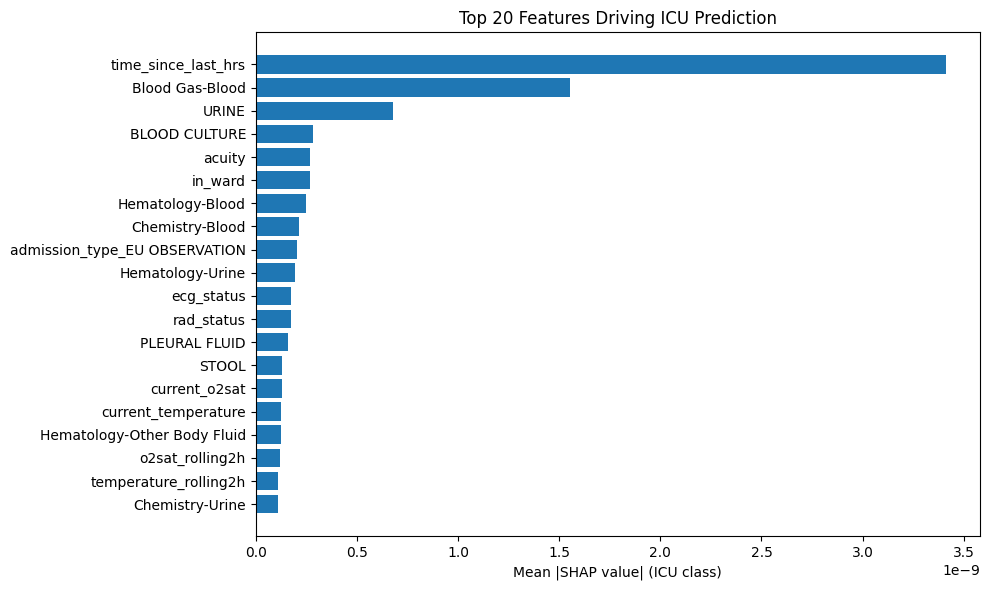

In [74]:
import shap

# GradientExplainer requires training mode for cuDNN RNN gradient computation
seq_model.train()

# Background: 200 random training samples
bg_idx  = torch.randperm(s_train.shape[0], generator=torch.Generator().manual_seed(10))[:200]
bg_data = s_train[bg_idx].to(device)

class ModelWrapper(nn.Module):
    def forward(self, x):
        lengths = torch.full((x.shape[0],), x.shape[1], dtype=torch.long)
        packed  = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        _, (h_n, _) = seq_model.lstm(packed)
        return seq_model.fc(h_n[-1])

wrapper = ModelWrapper().to(device)

n_explain = 200
exp_idx   = torch.randperm(s_test.shape[0], generator=torch.Generator().manual_seed(10))[:n_explain]
exp_data  = s_test[exp_idx].to(device)

explainer   = shap.GradientExplainer(wrapper, bg_data)
shap_values = explainer.shap_values(exp_data)

seq_model.eval()

# Inspect structure
if isinstance(shap_values, list):
    print(f'shap_values is a list of {len(shap_values)} arrays')
    for i, sv in enumerate(shap_values):
        print(f'  [{i}] shape: {np.array(sv).shape}')
    # ICU class = index 1 if 2 elements, else last axis
    shap_icu_raw = np.array(shap_values[1])
else:
    shap_values = np.array(shap_values)
    print(f'shap_values is an array of shape: {shap_values.shape}')
    # Newer shap: shape (n_explain, T, 124, 2) — take ICU class (axis -1, index 1)
    shap_icu_raw = shap_values[..., 1]

# Aggregate: mean |SHAP| across timesteps then samples -> (124,)
mean_shap = np.abs(shap_icu_raw).mean(axis=1).mean(axis=0)  # (124,)

# Plot top 20 features
top_idx   = np.argsort(mean_shap)[::-1][:20]
top_vals  = mean_shap[top_idx]
top_names = [state_cols[i] for i in top_idx]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_names[::-1], top_vals[::-1])
ax.set_xlabel('Mean |SHAP value| (ICU class)')
ax.set_title('Top 20 Features Driving ICU Prediction')
plt.tight_layout()
plt.show()


In [61]:
predicted_classes = final_preds.argmax(dim=1)
print(f"Predicted discharge: {(predicted_classes==0).sum():,} ({(predicted_classes==0).float().mean():.2%})")
print(f"Predicted ICU:       {(predicted_classes==1).sum():,} ({(predicted_classes==1).float().mean():.2%})")
print(f"\nTrue discharge: {(true_labels==0).sum():,} ({(true_labels==0).float().mean():.2%})")
print(f"True ICU:       {(true_labels==1).sum():,} ({(true_labels==1).float().mean():.2%})")


Predicted discharge: 13,129 (77.95%)
Predicted ICU:       3,714 (22.05%)

True discharge: 13,193 (78.33%)
True ICU:       3,650 (21.67%)


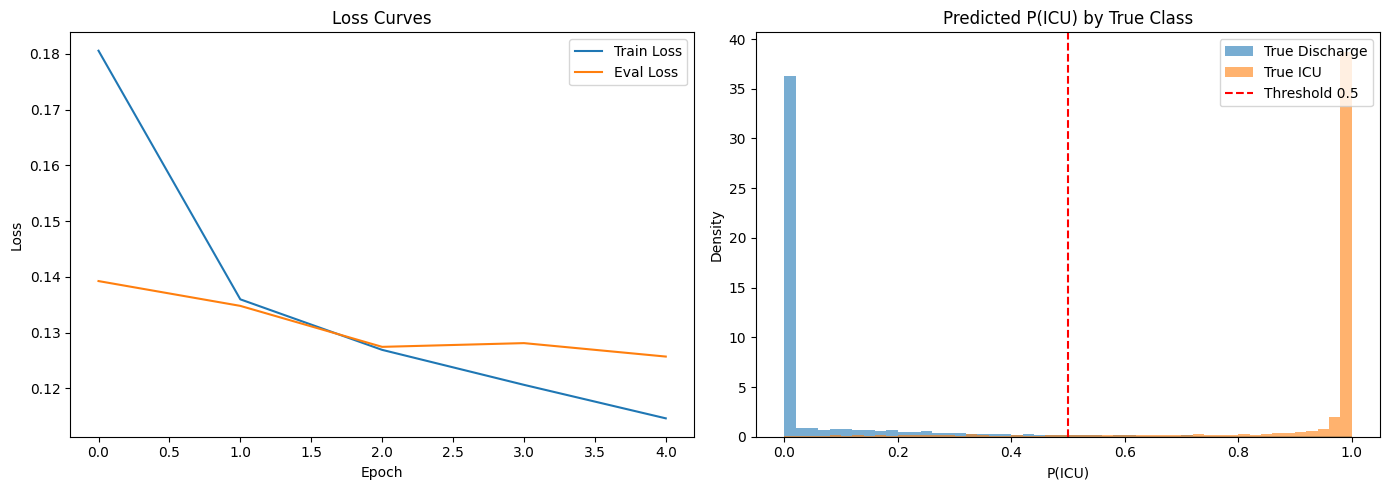

In [64]:
pred_probs = final_preds.numpy()  # (N, 2)
true_np    = true_labels.numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(eval_losses, label="Eval Loss")
axes[0].set_title("Loss Curves")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].hist(pred_probs[true_np==0, 1], bins=50, alpha=0.6, label="True Discharge", density=True)
axes[1].hist(pred_probs[true_np==1, 1], bins=50, alpha=0.6, label="True ICU", density=True)
axes[1].axvline(0.5, color="red", linestyle="--", linewidth=1.5, label="Threshold 0.5")
axes[1].set_title("Predicted P(ICU) by True Class")
axes[1].set_xlabel("P(ICU)")
axes[1].set_ylabel("Density")
axes[1].legend()

plt.tight_layout()
plt.show()


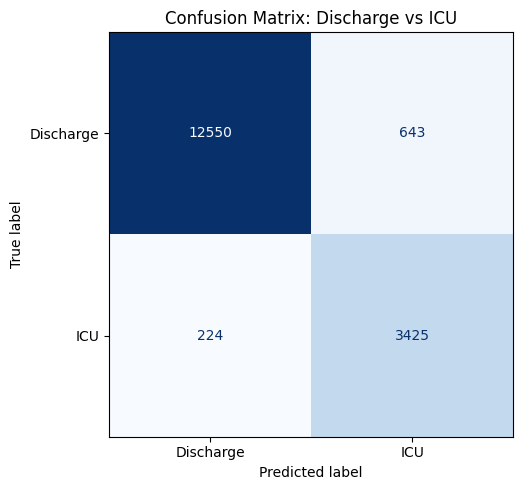

In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

predicted_classes = final_preds.argmax(dim=1).numpy()
true_np = true_labels.numpy()

cm = confusion_matrix(true_np, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Discharge", "ICU"])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix: Discharge vs ICU")
plt.tight_layout()
plt.show()


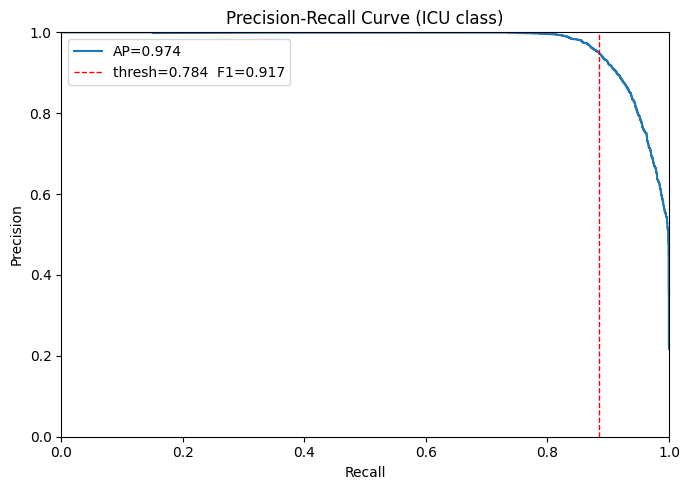

Optimal threshold: 0.7840
F1 at optimal:     0.9166
Average Precision: 0.9737


In [66]:
from sklearn.metrics import precision_recall_curve, average_precision_score

pred_np = final_preds.numpy()
true_np = true_labels.numpy()

prec, rec, thresh = precision_recall_curve(true_np, pred_np[:, 1])
ap = average_precision_score(true_np, pred_np[:, 1])
f1s = 2 * prec * rec / (prec + rec + 1e-8)
best_idx = f1s.argmax()
optimal_threshold = float(thresh[best_idx])

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec, prec, lw=1.5, label=f"AP={ap:.3f}")
ax.axvline(rec[best_idx], color="red", linestyle="--", linewidth=1,
           label=f"thresh={optimal_threshold:.3f}  F1={f1s[best_idx]:.3f}")
ax.set_title("Precision-Recall Curve (ICU class)")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Optimal threshold: {optimal_threshold:.4f}")
print(f"F1 at optimal:     {f1s[best_idx]:.4f}")
print(f"Average Precision: {ap:.4f}")
